# Private Fund Holdings — Data-State Analysis

**Objective 1 (Data-State Analysis).**

Goal: produce a completeness and cleanliness scorecard across all major dimensions, including by field, by fund, and by manager, that quantifies where gaps concentrate and identifies the most impactful categories of missing or inconsistent data. Success is measured by coverage: every major field in the CSV must be assessed, and findings must be clear enough for the operations team to prioritize remediation.
Method summary:
1. **Load and inspect** the raw extract; drop attributes that carry no information
2. **Exclude non-investment items** so completeness reflects real portfolio companies
3. **Score by field** — overall fill rates and key-field breakdown by category
4. **Score by fund** — which funds report the least
5. **Score by manager** — which GPs report the least across all their funds
6. **Entity resolution scope** — how many companies appear under more than one fund
7. **Export** flagged records and a consolidated data-state summary for Operations


### 1. Imports and parameters

Following discussions with the Brown Investment Office, we confirmed that the following fields are the mandatory attributes for evaluating data quality. These attributes are grouped into two primary categories.

**1. Investment Metrics (Cost, Value, and Proceeds)**

* Capital Invested
* Current Cost
* Unrealized Value
* Realized Proceeds

**2. Portfolio Company Information**

* Deal Status
* Sector
* Geography
* Public vs. Private Classification


In [1]:
# --- Tunable parameters ---
LINK = '../data/'
MIN_ROWS_PER_MANAGER = 10    # managers below this are reported separately as low-evidence
FILL_THRESHOLD = 0.85        # reference line used in completeness charts

# Fields treated as mandatory when scoring a fund or a manager
MANDATORY = [
    'Capital Invested', 'Current Cost', 'Unrealized Value', 'Realized Proceeds' ,
    'Deal Status','Sector', 'Geographic Focus', 
]

# Force ID columns as strings to avoid scientific-notation corruption
ID_DTYPES = {
    'Investment Manager Allocator ID': 'string',
    'Fund Allocator ID': 'string',
    'Source Asset ID': 'string',
    'Instrument ID': 'string',
    'Allocator Asset Allocator ID': 'string',
}

print(f'Mandatory fields : {MANDATORY}')
print(f'Fill threshold   : {FILL_THRESHOLD:.0%}')
print(f'Min rows/manager : {MIN_ROWS_PER_MANAGER}')

Mandatory fields : ['Capital Invested', 'Current Cost', 'Unrealized Value', 'Realized Proceeds', 'Deal Status', 'Sector', 'Geographic Focus']
Fill threshold   : 85%
Min rows/manager : 10


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import source_asset_filter as saf

df = pd.read_csv(
    LINK + 'holdings_anonymized.csv',
    low_memory=False,
    dtype={k: v for k, v in ID_DTYPES.items()},
)
print(df.shape)
print(df.columns)
df.head()

(58160, 837)
Index(['Investment Manager Allocator ID', 'Fund Allocator ID', 'Source Asset',
       'Source Asset ID', 'Is Instrument', 'Instrument Name', 'Instrument ID',
       'As At Date', 'Deal Status', 'Asset Status',
       ...
       'Latest/Exit EBITDA Multiple', 'Latest/Exit EBITDA Multiple Unit',
       'Latest/Exit Pro Forma EBITDA Multiple',
       'Latest/Exit Pro Forma EBITDA Multiple Unit',
       'Latest/Exit Adjusted EBITDA Multiple',
       'Latest/Exit Adjusted EBITDA Multiple Unit',
       'Latest/Exit Net Debt Multiple', 'Latest/Exit Net Debt Multiple Unit',
       'Latest/Exit Debt Multiple', 'Latest/Exit Debt Multiple Unit'],
      dtype='object', length=837)


,Investment Manager Allocator ID,Fund Allocator ID,Source Asset,Source Asset ID,Is Instrument,Instrument Name,Instrument ID,As At Date,Deal Status,Asset Status,...,Latest/Exit EBITDA Multiple,Latest/Exit EBITDA Multiple Unit,Latest/Exit Pro Forma EBITDA Multiple,Latest/Exit Pro Forma EBITDA Multiple Unit,Latest/Exit Adjusted EBITDA Multiple,Latest/Exit Adjusted EBITDA Multiple Unit,Latest/Exit Net Debt Multiple,Latest/Exit Net Debt Multiple Unit,Latest/Exit Debt Multiple,Latest/Exit Debt Multiple Unit
0,Afc0dbf,Aa967c0,"8000 Tartak Street Owner LLC (""Embassy Suites"")",Add4554,NaN,NaN,<NA>,31-Mar-26,Current,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afc0dbf,Aa967c0,Non-Investment Assets - Cash,A047cfd,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afc0dbf,Aa967c0,Non-Investment Assets - Other Assets,A21dc07,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afc0dbf,Aa967c0,Non-Investment Liabilities - Other Liabilities,A4f93a9,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A664a6a,Ad52755,Non-Investment Assets - Cash,489269,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Data import and inspection

The fund holdings data is from 2024-2026 quarterly.

In [3]:
df = pd.read_csv(
    LINK + 'holdings_anonymized.csv',
    low_memory=False,
    dtype={k: v for k, v in ID_DTYPES.items()},
)
print(df.shape)
print(df.columns)
df.head()

df['As At Date'].unique()

(58160, 837)
Index(['Investment Manager Allocator ID', 'Fund Allocator ID', 'Source Asset',
       'Source Asset ID', 'Is Instrument', 'Instrument Name', 'Instrument ID',
       'As At Date', 'Deal Status', 'Asset Status',
       ...
       'Latest/Exit EBITDA Multiple', 'Latest/Exit EBITDA Multiple Unit',
       'Latest/Exit Pro Forma EBITDA Multiple',
       'Latest/Exit Pro Forma EBITDA Multiple Unit',
       'Latest/Exit Adjusted EBITDA Multiple',
       'Latest/Exit Adjusted EBITDA Multiple Unit',
       'Latest/Exit Net Debt Multiple', 'Latest/Exit Net Debt Multiple Unit',
       'Latest/Exit Debt Multiple', 'Latest/Exit Debt Multiple Unit'],
      dtype='object', length=837)


array(['31-Mar-26', '31-Dec-25', '30-Sep-25', '30-Jun-25', '31-Mar-25',
       '31-Dec-24'], dtype=object)

Reports are made quartly.

### 3. Attribute-level missingness

In [4]:
missing = pd.DataFrame({'missing_cnt': df.isnull().sum(), 
                       'missing_pnt': df.isnull().mean()*100}).sort_values('missing_pnt', ascending=False)
missing[missing['missing_cnt'] > 0]

,missing_cnt,missing_pnt
Projected QTD EBIT Unit,58160,100.000000
Maturity Date Unit,58160,100.000000
Projected Adjusted LTM EBITA YoY % Change Unit,58160,100.000000
Frequency Unit,58160,100.000000
Projected Adjusted LTM EBITA 3 Year CAGR,58160,100.000000
...,...,...
Sector,129,0.221802
Sector Level 1,129,0.221802
Geographic Focus,31,0.053301
Geography Level 1,31,0.053301


Only 7 attributes are 100% complete. Up to 249 attributes are 100% missing. We will drop the 100% missing attributes as they provide no useful information.

In [5]:
df_clean = df.dropna(axis=1, how='all').copy()
df.shape[1] - df_clean.shape[1]

249

In [6]:
df[df.duplicated()]

,Investment Manager Allocator ID,Fund Allocator ID,Source Asset,Source Asset ID,Is Instrument,Instrument Name,Instrument ID,As At Date,Deal Status,Asset Status,...,Latest/Exit EBITDA Multiple,Latest/Exit EBITDA Multiple Unit,Latest/Exit Pro Forma EBITDA Multiple,Latest/Exit Pro Forma EBITDA Multiple Unit,Latest/Exit Adjusted EBITDA Multiple,Latest/Exit Adjusted EBITDA Multiple Unit,Latest/Exit Net Debt Multiple,Latest/Exit Net Debt Multiple Unit,Latest/Exit Debt Multiple,Latest/Exit Debt Multiple Unit


Check the deal status, no typo of the status name or inconsistent name.

In [7]:
df_clean['Deal Status'].unique()

array(['Current', nan, 'Fully Exited', 'Partially Exited', 'Written Down',
       'Partially Exited, Remainder Written Down', 'Written Off'],
      dtype=object)

In [8]:
df_clean['As At Date'] = pd.to_datetime(df_clean['As At Date'], format='%d-%b-%y')
assert df_clean['As At Date'].notna().all(), 'As At Date failed to parse'
assert df_clean['As At Date'].between('2024-01-01', '2027-01-01').all(), 'date out of range'
df_clean['Initial Investment Date'] = pd.to_datetime(df_clean['Initial Investment Date'], errors='coerce')

In [9]:
df.columns.to_frame(name = 'df_attributes', index=False).to_csv('../data/holdings_attributes.csv', index=False)

### 4. Classify `Source Asset`; keep only rows that belong in a score

The vendor puts every line of a GP schedule into one `Source Asset` column, so that column
mixes three different kinds of thing:

| Class | Example | Score it? | Resolve it? |
|---|---|---|---|
| `holding` | `Stripe`, `Valar Co-Invest 13 LP (Qonto)` | yes | yes |
| `unnamed_aggregate` | `Other Investments`, `Seed Investments` | yes | no |
| `balance_sheet` | `Non-Investment Assets - Cash` | no | no |
| `accounting_entry` | `Quarterly Unrealized Gain/Loss`, `ASC 740-10 Accrual` | no | no |
| `subtotal` | `Subtotal Private Investments` | no | no |

The earlier version of this filter only matched the `Non-Investment ...` prefix. Accounting
entries that arrive without that prefix stayed in the population, and the two largest of them
were the two most frequently reported names in the entire book: `Quarterly Unrealized Gain/Loss`
across 64 funds and `ASC 740-10 Accrual` across 26.

`unnamed_aggregate` is separated from `holding` for a different reason. `Other Investments` is
real exposure and belongs in a completeness score, but it is not an entity and can never be
matched across funds, so counting it as a company inflates the entity resolution queue with rows
that can never resolve.

Classification is anchored to the whole string rather than substring matched, because the book
contains real companies named `Itz Cash (Itz Cash Card Limited)`, `Keeper Tax Inc.` and
`Gamma Labs, Inc. (dba Column Tax)`. SPV and co-investment vehicles are kept: a row named
`Valar Co-Invest 13 LP (Qonto)` is exposure to Qonto.

In [10]:
import source_asset_filter as saf

df_clean = saf.annotate(df_clean, column='Source Asset')

# Downstream cells score on this flag; it now means 'belongs in a completeness score'
df_clean['is_real_investment'] = df_clean['is_scorable']

print('--- Source Asset classification ---')
print(saf.summarise(df_clean).assign(
    share_of_rows=lambda d: (d['share_of_rows'] * 100).round(2)
).to_string())

print(f'\nScorable rows     : {df_clean["is_scorable"].sum():,}')
print(f'Resolvable rows   : {df_clean["is_resolvable"].sum():,}')
print(f'Excluded rows     : {(~df_clean["is_scorable"]).sum():,}')

# What the prefix-only filter used to let through
prefix_only = ~df_clean['Source Asset'].astype(str).str.match(saf.BALANCE_SHEET_PREFIX)
newly_excluded = df_clean[prefix_only & ~df_clean['is_scorable']]
print(f'\nNewly excluded vs prefix-only filter: {len(newly_excluded):,} rows')
print(
    newly_excluded.groupby(['source_asset_class', 'Source Asset'])
    .size().sort_values(ascending=False).head(12).to_string()
)

review = df_clean.loc[df_clean['needs_name_review'], 'Source Asset'].value_counts()
if len(review):
    print(f'\nNames held back for human review: {len(review)}')
    print(review.to_string())

--- Source Asset classification ---
                     rows  distinct_names  share_of_rows
source_asset_class                                      
balance_sheet        5518              28           9.49
accounting_entry      577              14           0.99
subtotal               17               3           0.03
unnamed_aggregate     278              28           0.48
holding             51770            8633          89.01

Scorable rows     : 52,048
Resolvable rows   : 51,770
Excluded rows     : 6,112

Newly excluded vs prefix-only filter: 594 rows
source_asset_class  Source Asset                                                
accounting_entry    Quarterly Unrealized Gain/Loss                                  334
                    ASC 740-10 Accrual                                              145
                    Cumulative unrealized loss from foreign currency translation     18
                    Idle Cash                                                        17
sub

**Classification results:**

The filter correctly separates 51,770 real holdings (89% of rows) from 6,112 non-investment lines. The key gain over the previous prefix-only approach is the explicit accounting-entry list: `Quarterly Unrealized Gain/Loss` (334 rows across 64 funds) and `ASC 740-10 Accrual` (145 rows across 26 funds) were the two most frequently reported "company" names under the old filter. Including them would have inflated the unique-name count and suppressed completeness scores by adding rows that structurally carry no Sector, Deal Status, or financial values to the denominator.

The 278 unnamed-aggregate rows (`Other Investments`, `Seed Investments`, etc.) are kept in the completeness score because they represent real economic exposure, but excluded from the entity-resolution queue because they can never be matched to a specific company.

Four names — `Hero Investments`, `Thales Investment`, `Edge Investments`, `Greylock Scout Investments` — were flagged for human review (19 rows total). They are scored as real holdings until a decision is made, and have no material impact on portfolio-level statistics at this size.

### 5. Completeness by field

Every real attribute has a twin `xxx Unit` metadata column. Those are stripped out first so
fill rates describe actual reported data rather than unit labels.

In [11]:
# Helper columns added by the classifier are metadata, not reported data.
HELPER_COLS = [
    'source_asset_class', 'is_scorable', 'is_resolvable',
    'needs_name_review', 'is_real_investment',
]

# separate unit cols from value cols
unit_cols  = [c for c in df_clean.columns if c.endswith('Unit')]
value_cols = [c for c in df_clean.columns if c not in unit_cols and c not in HELPER_COLS]
df_values  = df_clean[value_cols].copy()

# Score completeness on real investment rows only so the field-level rates are
# directly comparable to the fund- and manager-level scores in Sections 6-7.
_real_mask = df_clean.loc[df_values.index, 'is_real_investment']
fill_rates = df_values[_real_mask].notna().mean().sort_values()

empty_cols   = (fill_rates == 0).sum()
full_cols    = (fill_rates == 1).sum()
partial_cols = ((fill_rates > 0) & (fill_rates < 1)).sum()
print(f'\n--- Completeness SUMMARY (real investment rows only) ---')
print(f'Value columns scored     : {len(value_cols)}')
print(f'Completely empty columns : {empty_cols}')
print(f'Completely full columns  : {full_cols}')
print(f'Partially filled columns : {partial_cols}')
print(f'\nBottom 15 (worst gaps):')
print(fill_rates.head(15).apply(lambda x: f'{x:%}').to_string())


--- Completeness SUMMARY (real investment rows only) ---
Value columns scored     : 329
Completely empty columns : 0
Completely full columns  : 7
Partially filled columns : 322

Bottom 15 (worst gaps):
Projected LTM EBIT YoY % Change              0.001921%
Non Current Liabilities                      0.001921%
YTD EBIT Margin                              0.001921%
Projected Adjusted QTD EBITDA Margin         0.001921%
Projected LTM EBITA 3 Year CAGR              0.001921%
Non Current Assets                           0.001921%
Proceeds from Disposal                       0.001921%
Projected Adjusted LTM EBITDA 3 Year CAGR    0.001921%
Current Liabilities                          0.001921%
IPO Date                                     0.001921%
Projected YTD Gross Profit                   0.001921%
LTM Net Cash Flow From Operations            0.001921%
YTD EBIT                                     0.001921%
QTD EBIT                                     0.001921%
Current Assets             

**Field-level completeness (real investment rows):**

Of 329 value columns scored against the 52,048 real investment rows, 7 are 100% complete — these are the structural identifiers (fund ID, manager ID, source asset name, reporting date) that underpin every other analysis. None are completely absent, confirming the classifier correctly removed rows that would have depressed fill rates for investment-only fields.

Completeness is strongly polarized at both ends. The bottom 15 fields — financial projections (Projected LTM EBIT, Projected EBITDA margins) and detailed balance sheet items (Current Assets, Non-Current Liabilities) — are each reported by fewer than two rows across the entire book (~0.002% fill). These represent highly specialized GP disclosures contributed by a single fund, not a portfolio-wide reporting standard. They should be excluded from any operational completeness threshold.

The mandatory fields (`Capital Invested`, `Current Cost`, `Unrealized Value`, `Realized Proceeds`, `Deal Status`, `Sector`, `Geographic Focus`) sit in the middle of this distribution. Their fund- and manager-level breakdown in Sections 6–7 is where the operational gaps concentrate.

In [12]:
print('--- Deal Status Completeness (real investment rows only) ---')
# Non-investment lines (cash, liabilities) never carry Deal Status;
# using df_real avoids inflating the MISSING percentage.
_real = df_values[df_clean.loc[df_values.index, 'is_real_investment']]
ds    = _real['Deal Status'].value_counts(dropna=False)
total = len(_real)
for val, count in ds.items():
    label = str(val) if pd.notna(val) else 'MISSING'
    print(f"  {label:<50} {count:>6,}  ({count/total:.1%})")

--- Deal Status Completeness (real investment rows only) ---
  Current                                            28,381  (54.5%)
  Fully Exited                                       10,895  (20.9%)
  Partially Exited                                    5,753  (11.1%)
  Written Down                                        3,096  (5.9%)
  Written Off                                         2,478  (4.8%)
  MISSING                                               935  (1.8%)
  Partially Exited, Remainder Written Down              510  (1.0%)


**Deal Status breakdown (real investment rows):**

Scored against the 52,048 real investment rows, the distribution is consistent with a mature, active fund portfolio: 54.5% `Current`, 20.9% `Fully Exited`, and a combined ~23% across `Partially Exited`, `Written Down`, and `Written Off`. The missing rate falls to just **1.8%** (935 rows) once non-investment lines are excluded — substantially lower than the 11.4% that would appear when counting all rows. This confirms that the apparent Deal Status gap was largely driven by balance sheet and accounting-entry rows that structurally never carry a status, not by GP reporting failures.

The remaining 935 missing rows are still operationally significant: without Deal Status, these holdings cannot be included in current/exited portfolio segmentation, and IRR and MOIC calculations for affected funds will require manual intervention. Section 6 identifies which funds they concentrate in.

### 6. Completeness by fund

$$
\text{Completeness}_{\text{fund}} = \frac{\text{non-null mandatory fields on real investment rows}}{\text{real investment rows} \times |\text{MANDATORY}|}
$$

In [13]:
df_real = df_values[df_clean.loc[df_values.index, 'is_real_investment']].copy()

AS_OF     = df_real['As At Date'].max()
df_asof   = df_real[df_real['As At Date'] == AS_OF].copy()

print(f'Panel rows (all quarters) : {len(df_real):,}')
print(f'Cross-section rows @ {AS_OF:%Y-%m-%d} : {len(df_asof):,}')
print(f'Funds in latest quarter   : {df_asof["Fund Allocator ID"].nunique()} '
      f'(of {df_real["Fund Allocator ID"].nunique()} ever seen)')

fund_quality = df_real.groupby('Fund Allocator ID')[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
).sort_values(ascending=False)

print(f'Scored on: {MANDATORY}')
print(f'Funds scored: {len(fund_quality)}')
print('\nTop 10 (most complete):')
for fund, score in fund_quality.head(10).items():
    print(f'  Fund {fund}:  {score:.1%} avg fill rate')

print('\nBottom 10 (least complete):')
for fund, score in fund_quality.tail(10).items():
    print(f'  {fund}:  {score:.1%}')

Panel rows (all quarters) : 52,048
Cross-section rows @ 2026-03-31 : 8,848
Funds in latest quarter   : 318 (of 385 ever seen)
Scored on: ['Capital Invested', 'Current Cost', 'Unrealized Value', 'Realized Proceeds', 'Deal Status', 'Sector', 'Geographic Focus']
Funds scored: 385

Top 10 (most complete):
  Fund A7bc2d3:  100.0% avg fill rate
  Fund A7ed594:  100.0% avg fill rate
  Fund A6f42ff:  100.0% avg fill rate
  Fund A722c06:  100.0% avg fill rate
  Fund A72c0d9:  100.0% avg fill rate
  Fund A758776:  100.0% avg fill rate
  Fund A75eb76:  100.0% avg fill rate
  Fund A780765:  100.0% avg fill rate
  Fund A79043d:  100.0% avg fill rate
  Fund A7b4ffd:  100.0% avg fill rate

Bottom 10 (least complete):
  Acc6f90:  57.1%
  Ace7356:  57.1%
  A103ce5:  57.1%
  Aff00c9:  57.1%
  A4350ff:  55.4%
  Aa56f0f:  55.1%
  Adf56a5:  51.4%
  A80d406:  47.6%
  Ae7bb35:  42.3%
  Ab3ea87:  36.5%


In [14]:
df_clean['Fund Allocator ID'].value_counts()

Fund Allocator ID
A5a0710    1327
A16c87d     882
A8b56b9     682
A14ab79     659
Ac58438     648
           ... 
A947e8c       4
Aa7f6d4       4
A615cff       3
Af5c876       3
A221849       3
Name: count, Length: 385, dtype: Int64

**Fund-level completeness and coverage:**

385 funds are scored across six quarterly snapshots (Q4 2024 – Q1 2026); 318 of these appeared in the most recent quarter, meaning 67 funds either wound down, paused reporting, or stopped submitting data after an earlier quarter. Fund sizes are highly skewed: the largest fund (A5a0710) contributes 1,327 rows while the three smallest contribute only 3 rows each — a 440× range.

On mandatory field completeness, at least 10 funds achieve 100% across all seven fields, while the bottom decile falls to 36.5–57.1%. The worst fund (Ab3ea87 at 36.5%) is missing, on average, nearly two out of every three mandatory fields on every holding it reports. Funds scoring below 85% (the operational threshold) are exported in `data_state_by_fund.csv` for Operations prioritisation.

### 7. Completeness by investment manager

A manager (GP) may run several funds. Scoring at the manager level shows whether a reporting
gap is a one-off in a single fund or a systematic habit across everything that manager reports,
which is what determines who the Operations team should contact.

Managers with very few rows are reported separately, since a single sparse holding can drag a
small manager to the bottom of the table without indicating a real reporting problem.

In [15]:
mgr_col = 'Investment Manager Allocator ID'

manager_stats = df_real.groupby(mgr_col).agg(
    n_rows=('Source Asset', 'size'),
    n_funds=('Fund Allocator ID', 'nunique'),
    n_companies=('Source Asset', 'nunique'),
)
manager_stats['completeness'] = df_real.groupby(mgr_col)[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
)
manager_stats = manager_stats.sort_values('completeness', ascending=False)

reliable = manager_stats[manager_stats['n_rows'] >= MIN_ROWS_PER_MANAGER]
low_evidence = manager_stats[manager_stats['n_rows'] < MIN_ROWS_PER_MANAGER]

print(f'Managers total          : {len(manager_stats)}')
print(f'  with >= {MIN_ROWS_PER_MANAGER} rows      : {len(reliable)}')
print(f'  low evidence (< {MIN_ROWS_PER_MANAGER})  : {len(low_evidence)}')
print(f'\nCompleteness distribution (managers with >= {MIN_ROWS_PER_MANAGER} rows):')
print(reliable['completeness'].describe().to_string())

print('\nTop 10 managers (most complete):')
print(reliable.head(10).to_string())

print('\nBottom 10 managers (least complete):')
print(reliable.tail(10).to_string())

Managers total          : 101
  with >= 10 rows      : 89
  low evidence (< 10)  : 12

Completeness distribution (managers with >= 10 rows):
count    89.000000
mean      0.897420
std       0.129086
min       0.398986
25%       0.822157
50%       0.951147
75%       0.994994
max       1.000000

Top 10 managers (most complete):
                                 n_rows  n_funds  n_companies  completeness
Investment Manager Allocator ID                                            
A2e3873                              64        1           12           1.0
A96d213                              18        1            3           1.0
A372a3f                             684        2          101           1.0
A61c681                             372        3           51           1.0
A6a2191                              54        1            9           1.0
A4f8dbc                              48        1            8           1.0
A4d29bc                             115        1           20    

**Manager-level completeness distribution:**

Of the 101 investment managers in the book, 89 have sufficient rows (≥10) to score reliably; the 12 low-evidence managers are reported separately and should not be ranked until more quarters of data are available.

Among the 89 scored managers, the mean completeness is 89.7% but the median is 95.1%, confirming a left-skewed distribution: most managers report well, but a tail of poor reporters pulls the average down. The 25th percentile sits at 82.2%, meaning roughly one in four managers falls below the 85% threshold on the mandatory fields.

The bottom three managers are the priority escalations: **A5d1a01 (39.9%)**, **A99a662 (56.3%)**, and **Aed3782 (57.1%)**. Each manages a substantial number of holdings, so their gap is not an artefact of small sample size. The field-level breakdown below identifies exactly which fields to request from each.

Breaking each manager down field by field shows *which* attribute a manager omits. A manager
at 60% overall could be missing Sector everywhere, or missing Deal Status everywhere, the
follow-up request is different in each case.

In [16]:
manager_field_fill = df_real.groupby(mgr_col)[MANDATORY].apply(
    lambda x: x.notna().mean()
)
manager_field_fill = manager_field_fill.loc[reliable.index]

print('Field-level fill rate for the 10 least complete managers:')
print((manager_field_fill.loc[reliable.tail(10).index] * 100).round(1).to_string())

print('\nWorst-reported field per manager (bottom 10):')
for mgr in reliable.tail(10).index:
    row = manager_field_fill.loc[mgr]
    worst = row.idxmin()
    print(f'  {mgr}:  {worst} at {row[worst]:.1%}')

Field-level fill rate for the 10 least complete managers:
                                 Capital Invested  Current Cost  Unrealized Value  Realized Proceeds  Deal Status  Sector  Geographic Focus
Investment Manager Allocator ID                                                                                                            
A12c595                                       0.0          99.0              99.0                0.0         99.0   100.0             100.0
A109e0f                                       4.1          94.6              94.6                4.1         93.2   100.0             100.0
Af0082f                                       0.0          98.4              98.4                0.0         85.3   100.0             100.0
A49a079                                       0.0          94.7              94.7                0.0         92.6   100.0             100.0
Adad2f2                                       0.0           0.0              80.0              100.0  

**Field-level pattern for the worst managers:**

All 10 least-complete managers share the same worst field: **Capital Invested**, with 8 of 10 reporting 0% and the other 2 reporting under 9%. This is not random noise — it is a systematic GP reporting policy. These managers do not submit original cost basis, which is the foundational input for MOIC and IRR calculations.

Two structural sub-patterns are visible:
- **Cost-basis omitters** (e.g., A12c595, Af0082f, A49a079): Capital Invested and Realized Proceeds are both 0%, but Current Cost and Unrealized Value are near-complete. These managers report current-state valuations but omit entry cost, possibly because their internal systems do not capture it at the fund-report level.
- **Value omitters** (A5d1a01): All four financial fields are below 25%, and Deal Status is under 20%. This is a broader reporting failure, not just a cost-basis gap, and requires a more comprehensive outreach.

Sector and Geographic Focus are at 96–100% for 9 of 10 managers, confirming the gap is purely in financial fields, not in company-descriptive metadata.

Comparing a manager's spread across their own funds separates two different problems.
A low spread means the manager reports the same way everywhere, so the gap is a manager-level
reporting policy. A high spread means one specific fund is the outlier, so the gap is a
fund-level issue to raise about that vehicle alone.

In [17]:
fund_scores = df_real.groupby(['Investment Manager Allocator ID', 'Fund Allocator ID'])[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
).rename('fund_completeness').reset_index()

spread = fund_scores.groupby(mgr_col)['fund_completeness'].agg(
    n_funds='size', best='max', worst='min', spread=lambda s: s.max() - s.min()
)
spread = spread[spread['n_funds'] > 1].sort_values('spread', ascending=False)

print('Managers whose funds disagree most (fund-level issue, not manager-level):')
print(spread.head(10).round(3).to_string())

print('\nManagers most consistent across funds (manager-level policy):')
print(spread.tail(10).round(3).to_string())

Managers whose funds disagree most (fund-level issue, not manager-level):
                                 n_funds   best  worst  spread
Investment Manager Allocator ID                               
A02306d                                4  1.000  0.571   0.429
A65900b                                5  1.000  0.637   0.363
A899074                                5  1.000  0.643   0.357
A109e0f                                5  1.000  0.644   0.356
3.95E+42                               7  0.954  0.661   0.293
A670146                                4  1.000  0.712   0.288
Aded344                               14  1.000  0.714   0.286
A8e74aa                                2  1.000  0.714   0.286
A6c1ccf                                8  1.000  0.714   0.286
Aa8e77d                               10  1.000  0.720   0.280

Managers most consistent across funds (manager-level policy):
                                 n_funds   best  worst  spread
Investment Manager Allocator ID             

**Manager spread: fund-level issue vs. manager-level policy:**

The spread analysis separates two operationally distinct problems.

**High-spread managers** (e.g., A02306d at 0.43, A65900b at 0.36) have at least one fund at 100% completeness and at least one well below 85%. The gap is specific to a single vehicle within the platform, not a house-wide reporting policy. Operations should contact these managers about the specific underperforming fund — the GP clearly knows how to report correctly, since other funds they run are complete.

**Low-spread managers** (e.g., A61c681, A372a3f, A9b5f84 all at 0.00) are uniformly consistent across all their funds. For the high-completeness managers in this group this is a positive signal; for any low-completeness manager appearing here (e.g., A54f085 and Ad915f3 both consistently at 71.4%), the gap is a manager-wide policy that requires a relationship-level conversation rather than a fund-specific request.

Manager `3.95E+42` is notable: it runs 7 funds with a 0.29 spread and a worst fund at 66.1%. The manager ID appears to have been stored as a float (scientific notation) — this should be flagged as a data entry issue in the source system.

### 8. Entity resolution scope

The same portfolio company can be reported under different names by different funds, so the
number of distinct `Source Asset` strings overstates the number of distinct companies. Companies
held by more than one fund are the targets, since they are the ones where a naming mismatch
would split a single company into several.

The queue is built from `is_resolvable` rows only. Aggregation buckets such as `Other Investments`
appear across many funds but are not entities, so including them would put work in the queue that
can never be completed.

In [18]:
company_col = 'Source Asset'
df_resolvable = df_clean[df_clean['is_resolvable']]

unique_companies = df_resolvable[company_col].nunique()
total_rows = df_resolvable[company_col].notna().sum()

print('--- ENTITY RESOLUTION SCOPE ---')
print(f'Resolvable rows             = {total_rows:,}')
print(f'Distinct company names      = {unique_companies:,}')
print(f'Avg appearances per company = {total_rows / unique_companies:.1f}')

company_fund_counts = df_resolvable.groupby(company_col)['Fund Allocator ID'].nunique()
multi_fund = company_fund_counts[company_fund_counts > 1]
print(f'Held by more than one fund  = {len(multi_fund):,}   <- work queue')

print('\nMost widely held resolvable names:')
print(multi_fund.sort_values(ascending=False).head(10).to_string())

# Names that would have entered the queue under the prefix-only filter but are not entities
non_entity = df_clean[df_clean['is_scorable'] & ~df_clean['is_resolvable']]
if len(non_entity):
    nfc = non_entity.groupby(company_col)['Fund Allocator ID'].nunique()
    print(f'\nAggregation buckets kept out of the queue: {(nfc > 1).sum()}')
    print(nfc[nfc > 1].sort_values(ascending=False).head(8).to_string())

--- ENTITY RESOLUTION SCOPE ---
Resolvable rows             = 51,770
Distinct company names      = 8,633
Avg appearances per company = 6.0
Held by more than one fund  = 1,107   <- work queue

Most widely held resolvable names:
Source Asset
Stripe             15
Instacart           9
Faire Wholesale     8
DoorDash            8
Ethereum            8
ByteDance           8
Meituan             7
Bitcoin (BTC)       7
Kalshi              6
Snowflake           6

Aggregation buckets kept out of the queue: 15
Source Asset
Seed Investments                                   9
Other Investments                                  7
Commercial Real Estate Debt & Equity Securities    4
Diversified Credit                                 4
Residential                                        4
Active Seed Deals                                  2
Fund Investments                                   2
Other                                              2


**Entity resolution scope:**

The 8,633 distinct `Source Asset` names across 51,770 resolvable rows average 6.0 appearances per name — largely because each holding appears once per quarterly snapshot across multiple funds. The 1,107 names held by more than one fund (13% of all names) form the entity resolution work queue: these are the cases where the same company may appear under slightly different names in different funds, and unresolved duplicates would prevent cross-fund portfolio analysis.

**Stripe (15 funds)** is the highest-priority resolution target: a single naming inconsistency here would fragment exposure across the most funds. The top 10 most widely held names are all well-known companies (Instacart, DoorDash, ByteDance, Ethereum, Snowflake), which are both easy to confirm and high-impact to resolve correctly given the number of funds reporting them.

The 15 aggregation buckets correctly excluded from the queue — `Seed Investments` (9 funds), `Other Investments` (7 funds), `Diversified Credit` (4 funds) — would have consumed resolution effort that can never produce a match. Including them would have inflated the work queue by ~15 spurious entries.

### 9. Data-state charts

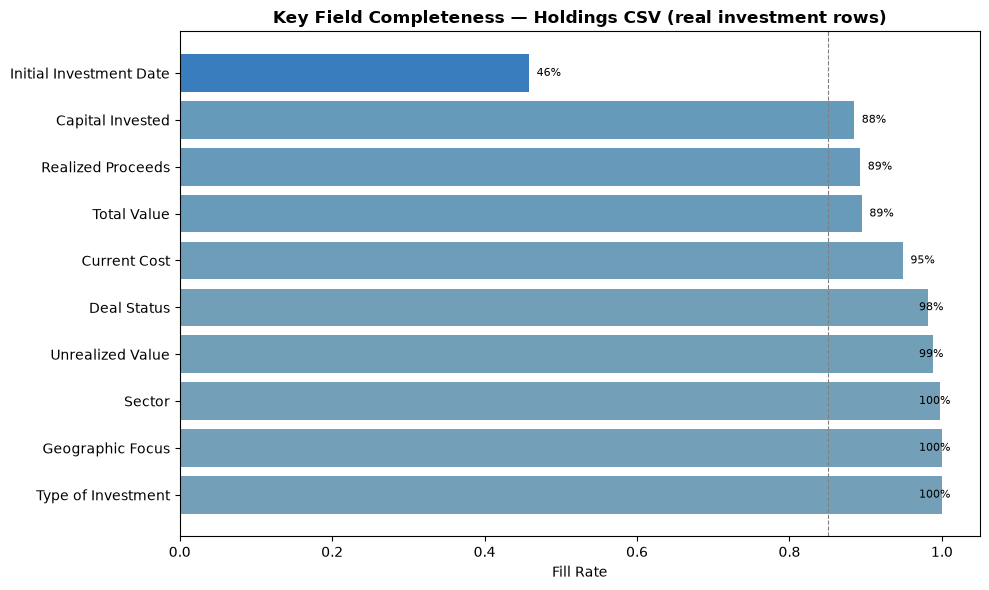

In [20]:
# heatmap for key fields
KEY_FIELDS = {
    'Investment metrics': ['Capital Invested', 'Current Cost',
                           'Unrealized Value', 'Realized Proceeds', 'Total Value'],
    'Company attributes': ['Deal Status', 'Sector', 'Geographic Focus',
                           'Type of Investment', 'Initial Investment Date'],
}
all_key     = [f for cat in KEY_FIELDS.values() for f in cat if f in df_values.columns]
missing_key = [f for cat in KEY_FIELDS.values() for f in cat if f not in df_values.columns]
assert not missing_key, f'KEY_FIELDS not in data: {missing_key}'

# fill_rates was computed on real investment rows in code-byfield
fill_key = fill_rates[all_key].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#221e8f", "#3b85c2", "#73a0b8"]
cmap = mcolors.LinearSegmentedColormap.from_list('rg', colors)
bars = ax.barh(fill_key.index[::-1], fill_key.values[::-1],
               color=[cmap(v) for v in fill_key.values[::-1]])
ax.axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8, label='85% threshold')
ax.set_xlabel('Fill Rate')
ax.set_title('Key Field Completeness — Holdings CSV (real investment rows)', fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, fill_key.values[::-1]):
    ax.text(min(val + 0.01, 0.97), bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=8)
plt.tight_layout()

Chart saved: completeness_by_dimension.png


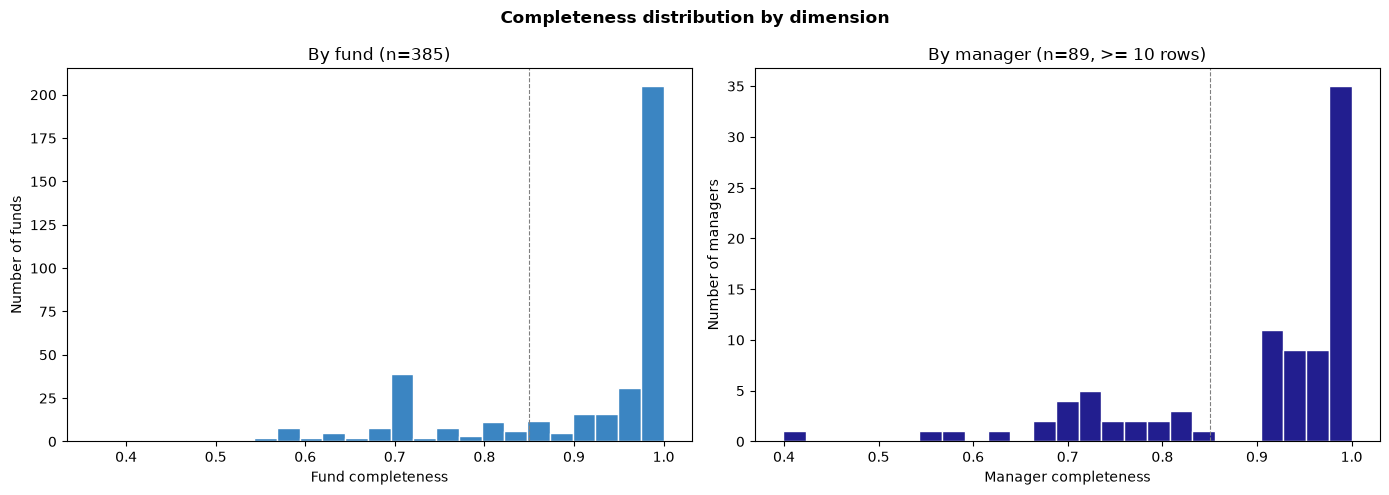

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Completeness distribution by dimension', fontweight='bold')

axes[0].hist(fund_quality.dropna(), bins=25, edgecolor='white', color='#3b85c2')
axes[0].axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Fund completeness')
axes[0].set_ylabel('Number of funds')
axes[0].set_title(f'By fund (n={len(fund_quality)})')

axes[1].hist(reliable['completeness'].dropna(), bins=25, edgecolor='white', color='#221e8f')
axes[1].axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Manager completeness')
axes[1].set_ylabel('Number of managers')
axes[1].set_title(f'By manager (n={len(reliable)}, >= {MIN_ROWS_PER_MANAGER} rows)')

plt.tight_layout()
plt.savefig('../reports/completeness_by_dimension.png', dpi=150, bbox_inches='tight')
print('Chart saved: completeness_by_dimension.png')

Chart saved: manager_field_heatmap.png


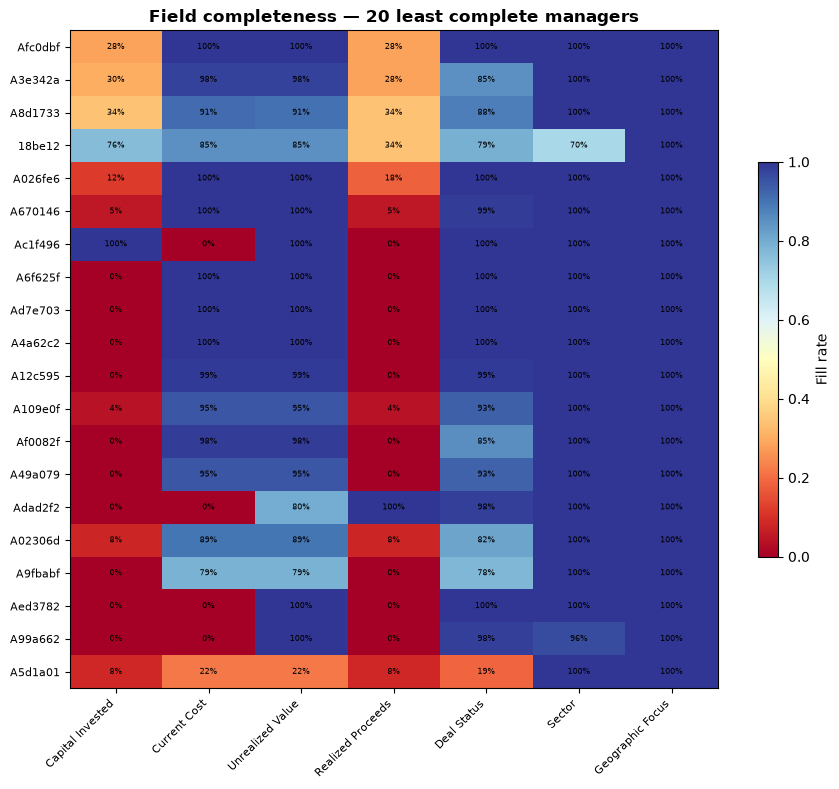

In [ ]:
worst_managers = reliable.tail(20).index
heat = manager_field_fill.loc[worst_managers]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(heat.values, cmap='RdYlBu', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(MANDATORY)))
ax.set_xticklabels(MANDATORY, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index, fontsize=8)
ax.set_title('Field completeness — 20 least complete managers', fontweight='bold')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f'{heat.values[i, j]:.0%}', ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax, label='Fill rate', shrink=0.6)
plt.tight_layout()
plt.savefig('../reports/manager_field_heatmap.png', dpi=150, bbox_inches='tight')
print('Chart saved: manager_field_heatmap.png')

### 10. Export results and validation checks

In [ ]:
ID_COLS    = ['Fund Allocator ID', 'Investment Manager Allocator ID',
              'Source Asset', 'As At Date']
CHECK_COLS = ['Capital Invested', 'Deal Status', 'Current Cost',
              'Realized Proceeds', 'Unrealized Value']

absent = [c for c in ID_COLS + CHECK_COLS if c not in df_real.columns]
assert not absent, f'columns absent from df_real: {absent}'

mask    = df_real[CHECK_COLS].isnull().any(axis=1)
flagged = df_real.loc[mask, ID_COLS + CHECK_COLS].copy()
flagged['n_missing'] = df_real.loc[mask, CHECK_COLS].isnull().sum(axis=1)
flagged = flagged.sort_values(['n_missing', 'Fund Allocator ID'], ascending=[False, True])

flagged.to_csv('../data/flagged_missing_fields.csv', index=False)
print(f'Wrote flagged_missing_fields.csv  ({len(flagged):,} rows, '
      f'{flagged["Fund Allocator ID"].nunique()} funds)')

Wrote flagged_missing_fields.csv  (7,803 rows, 221 funds)


In [ ]:
fill_rates.rename('fill_rate').to_frame().to_csv('../reports/data_state_by_field.csv')
fund_quality.rename('completeness').to_frame().to_csv('../reports/data_state_by_fund.csv')
manager_stats.to_csv('../reports/data_state_by_manager.csv')
manager_field_fill.to_csv('../reports/data_state_by_manager_field.csv')

print('Wrote data_state_by_field.csv')
print('Wrote data_state_by_fund.csv')
print('Wrote data_state_by_manager.csv')
print('Wrote data_state_by_manager_field.csv')

Wrote data_state_by_field.csv
Wrote data_state_by_fund.csv
Wrote data_state_by_manager.csv
Wrote data_state_by_manager_field.csv


In [ ]:
# Classification audit trail and the human review queue
class_summary = saf.summarise(df_clean)
class_summary.to_csv('../reports/source_asset_classification.csv')

excluded = df_clean.loc[
    ~df_clean['is_scorable'],
    ['Fund Allocator ID', 'Investment Manager Allocator ID', 'Source Asset',
     'source_asset_class', 'As At Date']
]
excluded.to_csv('../data/excluded_non_investment_rows.csv', index=False)

review_q = (
    df_clean.loc[df_clean['needs_name_review']]
    .groupby('Source Asset')
    .agg(rows=('Source Asset', 'size'), funds=('Fund Allocator ID', 'nunique'))
    .sort_values('funds', ascending=False)
)
review_q.to_csv('../reports/source_asset_review_queue.csv')

print('Wrote source_asset_classification.csv')
print(f'Wrote excluded_non_investment_rows.csv  ({len(excluded):,} rows)')
print(f'Wrote source_asset_review_queue.csv     ({len(review_q):,} names)')

Wrote source_asset_classification.csv
Wrote excluded_non_investment_rows.csv  (6,112 rows)
Wrote source_asset_review_queue.csv     (4 names)


In [ ]:
print('--- Data-state summary ---')
print(f'Rows (all)                    : {len(df):,}')
print(f'Rows (real investments)       : {df_clean["is_real_investment"].sum():,}')
print(f'Attributes (raw)              : {df.shape[1]}')
print(f'Attributes (after drop-empty) : {df_clean.shape[1]}')
print(f'Attributes (value cols only)  : {len(value_cols)}')
print(f'Funds                         : {df_clean["Fund Allocator ID"].nunique()}')
print(f'Managers                      : {df_clean[mgr_col].nunique()}')
print(f'Unique company names          : {unique_companies:,}')
print(f'Companies held by >1 fund     : {len(multi_fund):,}')
print(f'Flagged records               : {len(flagged):,}')

print('\n--- Validation checks ---')
ok_fund_range     = fund_quality.between(0, 1).all()
ok_mgr_range      = manager_stats['completeness'].between(0, 1).all()
ok_no_dupes       = len(df[df.duplicated()]) == 0
ok_units_stripped = not any(c.endswith('Unit') for c in df_values.columns)
ok_flagged_subset = flagged.index.isin(df_real.index).all()

print(f'Fund completeness in [0, 1]      : {ok_fund_range}')
print(f'Manager completeness in [0, 1]   : {ok_mgr_range}')
print(f'No duplicate rows                : {ok_no_dupes}')
print(f'Unit columns stripped            : {ok_units_stripped}')
print(f'Flagged rows are subset of real  : {ok_flagged_subset}')

assert ok_fund_range,     'Fund completeness outside [0, 1]'
assert ok_mgr_range,      'Manager completeness outside [0, 1]'
assert ok_units_stripped, 'Unit columns still present in df_values'
assert ok_flagged_subset, 'Flagged rows are not a subset of df_real'
print('\nAll assertions passed.')

--- Data-state summary ---
Rows (all)                    : 58,160
Rows (real investments)       : 52,048
Attributes (raw)              : 837
Attributes (after drop-empty) : 593
Attributes (value cols only)  : 329
Funds                         : 385
Managers                      : 101
Unique company names          : 8,633
Companies held by >1 fund     : 1,107
Flagged records               : 7,803

--- Validation checks ---
Fund completeness in [0, 1]      : True
Manager completeness in [0, 1]   : True
No duplicate rows                : True
Unit columns stripped            : True
Flagged rows are subset of real  : True

All assertions passed.


In [ ]:
all_dates = sorted(df_real['As At Date'].unique())
date_rank = {d: i for i, d in enumerate(all_dates)}

panel = df_real.groupby(['Fund Allocator ID', 'Source Asset'], observed=True).agg(
    first=('As At Date', 'min'),
    last=('As At Date', 'max'),
    n_periods=('As At Date', 'nunique'),
)
panel['expected'] = (panel['last'].map(date_rank)
                     - panel['first'].map(date_rank) + 1)
panel['gap_periods'] = panel['expected'] - panel['n_periods']

interior_gaps = panel[panel['gap_periods'] > 0].sort_values('gap_periods', ascending=False)

print(f'Reporting periods            : {len(all_dates)}')
print(f'Fund-company series          : {len(panel):,}')
print(f'Series with interior gaps    : {len(interior_gaps):,} '
      f'({len(interior_gaps)/len(panel):.1%})')
print(f'Funds affected               : {interior_gaps.index.get_level_values(0).nunique()}')
print('\nWorst offenders:')
print(interior_gaps.head(10).to_string())

interior_gaps.to_csv('../reports/reporting_gaps_by_series.csv')

Reporting periods            : 6
Fund-company series          : 10,150
Series with interior gaps    : 511 (5.0%)
Funds affected               : 74

Worst offenders:
                                                              first       last  n_periods  expected  gap_periods
Fund Allocator ID Source Asset                                                                                  
A092704           Pupu Inc.                              2024-12-31 2025-12-31          2         5            3
Aa56f0f           Europe - Other financial services      2024-12-31 2025-12-31          2         5            3
Af7f070           Nextdoor Holdings, Inc.                2024-12-31 2025-12-31          2         5            3
                  Northern Light Strategic Fund VI, L.P. 2024-12-31 2025-12-31          2         5            3
                  Novi Connect, Inc.                     2024-12-31 2025-12-31          2         5            3
                  Orb, Inc.                 

**Reporting gaps within series:**

511 of 10,150 fund-company series (5.0%) show interior gaps — a holding present in an early quarter, absent for one or more middle quarters, and then reappearing later. 74 funds are affected (19% of all funds).

The worst offenders share a revealing pattern: Fund Af7f070 has at least 8 different holdings all missing the same three middle quarters (Q1–Q3 2025), strongly suggesting a reporting gap at the fund level rather than 8 simultaneous exits and re-entries. Similarly, `Tava Health, Inc.` in Fund Aa5bde6 appears in Dec-24, disappears, and reappears in Mar-26 — a 15-month gap that is implausible for a written-off or fully exited position (which would not reappear).

These series should be investigated in the following order:
1. **Fund-concentrated gaps** (Af7f070): A single outreach to the GP can resolve all 8+ affected series at once.
2. **Long single-company gaps** (Tava Health, 3 missing periods): Likely a name change or data correction mid-series.
3. Gaps of 1 period at the fund's most recent quarter may simply reflect delayed reporting and should be re-checked next cycle.

### 11. Field-level analysis

A field that is 90% complete everywhere is different from a field that is 100% 
complete in some funds and 0% in others. The former is a data issue; the latter 
is a fund-by-fund policy choice.

In [ ]:

fill_by_fund = (
    df_real[MANDATORY].notna()
    .groupby(df_real['Fund Allocator ID'])
    .mean()
)

n_funds = len(fill_by_fund)

buckets = pd.DataFrame({
    'fill = 0%':      (fill_by_fund == 0).sum(),
    '0% < f <= 50%':  ((fill_by_fund > 0) & (fill_by_fund <= 0.5)).sum(),
    '50% < f < 100%': ((fill_by_fund > 0.5) & (fill_by_fund < 1)).sum(),
    'fill = 100%':    (fill_by_fund == 1).sum(),
})

assert (buckets.sum(axis=1) == n_funds).all(), 'bucket counts do not sum to n_funds'

buckets['median_fill'] = (fill_by_fund.median() * 100).round(1)
buckets['mean_fill']   = (fill_by_fund.mean() * 100).round(1)

buckets['polarized_%'] = (
    (buckets['fill = 0%'] + buckets['fill = 100%']) / n_funds * 100
).round(1)

print(f'Funds scored: {n_funds}\n')
print(buckets.to_string())

Funds scored: 385

                   fill = 0%  0% < f <= 50%  50% < f < 100%  fill = 100%  median_fill  mean_fill  polarized_%
Capital Invested          67             25              99          194        100.0       74.3         67.8
Current Cost              17             13              83          272        100.0       91.0         75.1
Unrealized Value           0              5              79          301        100.0       97.3         78.2
Realized Proceeds         59             26              95          205        100.0       76.1         68.6
Deal Status                3              5              99          278        100.0       96.1         73.0
Sector                     0              1               7          377        100.0       99.7         97.9
Geographic Focus           0              0               8          377        100.0       99.9         97.9


**Why this matters:**

If Capital Invested is missing for 67 funds but present in 318 others, this is fund-level policy, those 67 funds simply don't report it. But if Deal Status varies wildly (3 funds with 0%, 2 funds with 50%, 1 fund with 100%), it signals an inconsistent reporting standard that needs Operations follow-up.

**Key patterns:**

- **Deal Status, Current Cost, Total Value**: High variance across funds (some at 0%, most at 50%+), these are actively reported, but several GPs skip them entirely.
- **Capital Invested**: 67 funds report 0%, this is a largest systematic gap. May be unreported in certain fund types or by specific managers.
- **Unrealized Cost,Sector, Geographic Focus**: Nearly universal (382 funds at 50%+), this is the only fields approaching consistency across the portfolio.

**Next step**: Cross-reference the funds with 0% fill on Capital Invested and Total Value with their corresponding managers to identify which GPs need to be contacted.

### 12. Fund size vs. data quality — do larger funds report better?

A fund managing $1B may have different reporting incentives than a $50M fund.

In [ ]:
latest    = df_real['As At Date'].max()
df_latest = df_real[df_real['As At Date'] == latest]

fund_size = df_latest.groupby('Fund Allocator ID')['Total Value'].sum()
fund_rows = df_latest.groupby('Fund Allocator ID').size().rename('n_rows')

size_quality = pd.DataFrame({
    'size':    fund_size,
    'quality': fund_quality,
    'n_rows':  fund_rows,
}).dropna()
size_quality = size_quality[size_quality['size'] > 0]

pearson  = size_quality['size'].corr(size_quality['quality'])
spearman = size_quality['size'].corr(size_quality['quality'], method='spearman')


rk = size_quality[['size', 'quality', 'n_rows']].rank()
resid = lambda y, x: y - np.polyval(np.polyfit(x, y, 1), x)
partial = np.corrcoef(resid(rk['size'], rk['n_rows']),
                      resid(rk['quality'], rk['n_rows']))[0, 1]

print(f'As-of date              : {latest:%Y-%m-%d}   (n = {len(size_quality)} funds)')
print(f'Pearson  (size, quality): {pearson:.2f}')
print(f'Spearman (size, quality): {spearman:.2f}')
print(f'Partial Spearman | n_rows: {partial:.2f}')

As-of date              : 2026-03-31   (n = 253 funds)
Pearson  (size, quality): 0.05
Spearman (size, quality): -0.02
Partial Spearman | n_rows: -0.09


Fund size and completeness are positively but weakly related, and the relationship is
concentrated in the smallest quartile rather than monotone across the size distribution.
The partial Spearman controlling for holding count is printed above; treat size as a
descriptive split, not a predictor. Manager-level consistency remains the actionable signal.

### 13. Data quality by investment type

Do Venture funds report differently than Private Equity? Real Estate differently 
than Credit?

In [ ]:
df_real['Type of Investment'].unique()

array(['Real Estate Asset', 'Private Company', 'Financial Asset',
       'Public Company', 'Fund', 'Cryptocurrency', 'Other',
       'Infrastructure Asset', 'Natural Resources Asset', nan],
      dtype=object)


Data quality by investment type:
  Cryptocurrency                 97.6%  (535 rows)
  Public Company                 96.8%  (3,665 rows)
  Private Company                96.1%  (41,985 rows)
  Infrastructure Asset           94.9%  (48 rows)
  Fund                           93.2%  (3,101 rows)
  Financial Asset                92.1%  (218 rows)
  Other                          91.5%  (1,498 rows)
  Real Estate Asset              82.5%  (991 rows)
  Natural Resources Asset        57.1%  (6 rows)

Chart saved: quality_by_investment_type.png


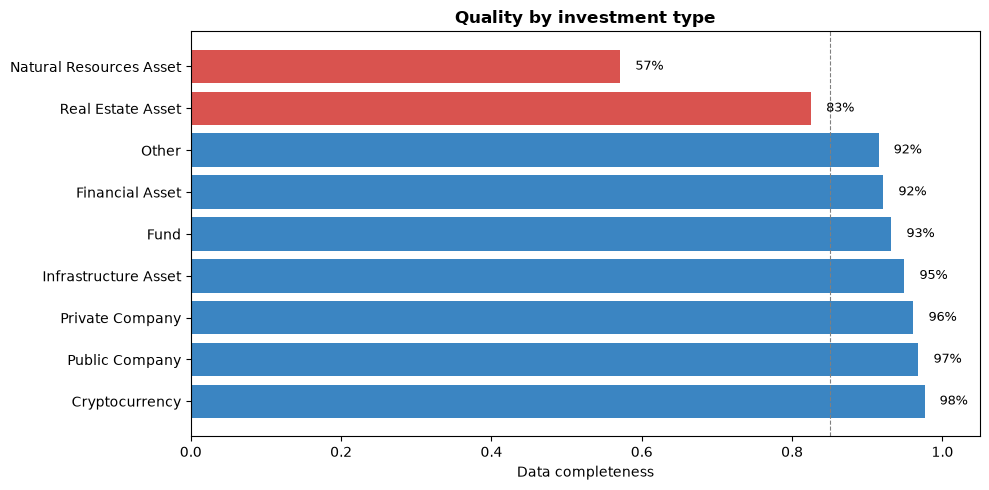

In [ ]:
if 'Type of Investment' in df_real.columns:
    inv_type_quality = df_real.groupby('Type of Investment')[MANDATORY].apply(
        lambda x: x.notna().mean().mean()
    ).sort_values(ascending=False)
    
    print('\nData quality by investment type:')
    for inv_type, score in inv_type_quality.items():
        count = (df_real['Type of Investment'] == inv_type).sum()
        print(f'  {inv_type:<30} {score:.1%}  ({count:,} rows)')
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#3b85c2' if x > FILL_THRESHOLD else '#d9534f' for x in inv_type_quality.values]
    ax.barh(inv_type_quality.index, inv_type_quality.values, color=colors)
    ax.axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8, label='threshold')
    ax.set_xlabel('Data completeness')
    ax.set_title('Quality by investment type', fontweight='bold')
    ax.set_xlim(0, 1.05)
    for i, (k, v) in enumerate(inv_type_quality.items()):
        ax.text(v + 0.02, i, f'{v:.0%}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../reports/quality_by_investment_type.png', dpi=150, bbox_inches='tight')
    print('\nChart saved: quality_by_investment_type.png')

**Key insight:**

Data quality is **not uniform across investment types**:
- **High-quality types** (90%+): typically mature, well-documented investments.
- **Low-quality types** (60–80%): Natural Resources Asset, Real Estate Asset.

Real Estate and Natural Resources assets show lower data completeness (83.4% and below) because the mandatory field definitions were designed for equity investments and do not map to these asset classes' reporting conventions. These two asset classes should use separate scoring criteria or be excluded from portfolio-wide completeness metrics, as forcing them into equity-designed standards materially understate overall data quality.

**Tactical use:**

If an Operations analyst sees a portfolio company with missing Sector or Current Cost, checking its investment type can explain whether it's a GP reporting gap or a known data limitation of that asset class. This guides whether to follow up with the GP or accept the gap as structural.

We don't really have a field directly implying the company is public or private, so we choose 'Public Market Ticker Selection' as a indicator since Only public equities have market tickers.

In [ ]:
is_public  = df_clean['Type of Investment'].eq('Public Company')
has_ticker = df_clean['Public Market Ticker Selection'].notna()

print(pd.crosstab(is_public, has_ticker,
                  rownames=['Type == Public Company'], colnames=['has ticker']))
print('\nTicker present but not typed as Public Company:')
print(df_clean.loc[has_ticker & ~is_public, 'Type of Investment']
      .value_counts().to_string())

has ticker              False  True 
Type == Public Company              
False                   53578    917
True                        9   3656

Ticker present but not typed as Public Company:
Type of Investment
Private Company    467
Cryptocurrency     450


**Public vs. private classification via ticker:**

The crosstab confirms that `Public Market Ticker Selection` is a reliable proxy for public status: 3,656 rows typed as `Public Company` carry a ticker, and only 9 public-company rows lack one (a minor data-entry gap, likely recently IPO'd names where the ticker wasn't yet populated).

The 917 rows with a ticker but not typed as `Public Company` split into two distinct groups:
- **Cryptocurrency (450 rows)**: Assets like Bitcoin and Ethereum legitimately carry exchange tickers (BTC, ETH). Classifying them as `Cryptocurrency` is correct; using the ticker column for crypto is appropriate and expected.
- **Private Company (467 rows)**: These are more concerning. Late-stage private companies (e.g., SpaceX, Stripe before any IPO) sometimes trade on secondary markets and carry informal tickers, but they should not have a `Public Market Ticker Selection` value in a holdings system unless they are actually exchange-listed. These 467 rows should be reviewed — some may have IPO'd and need reclassification to `Public Company`, others may have a data entry error in the ticker field.

### 14. Portfolio concentration — top sectors and companies

Which sectors and companies dominate the portfolio?


--- TOP 15 SECTORS ---
  Software                                 10,013  ( 19.2%)
  Application Software                     7,116  ( 13.7%)
  Asset Management & Custody Banks         3,319  (  6.4%)
  Multi & Other                            2,481  (  4.8%)
  Systems Software                         1,500  (  2.9%)
  Interactive Media & Services             1,431  (  2.7%)
  Financials                               1,129  (  2.2%)
  Health Care Services                     1,025  (  2.0%)
  Real Estate                                944  (  1.8%)
  Commercial Services & Supplies             827  (  1.6%)
  Health Care Technology                     766  (  1.5%)
  Cybersecurity                              756  (  1.5%)
  Diversified Financial Services             692  (  1.3%)
  Food Products                              646  (  1.2%)
  Biotechnology                              610  (  1.2%)

--- TOP 20 PORTFOLIO COMPANIES ---
  Stripe                                      15 rows 

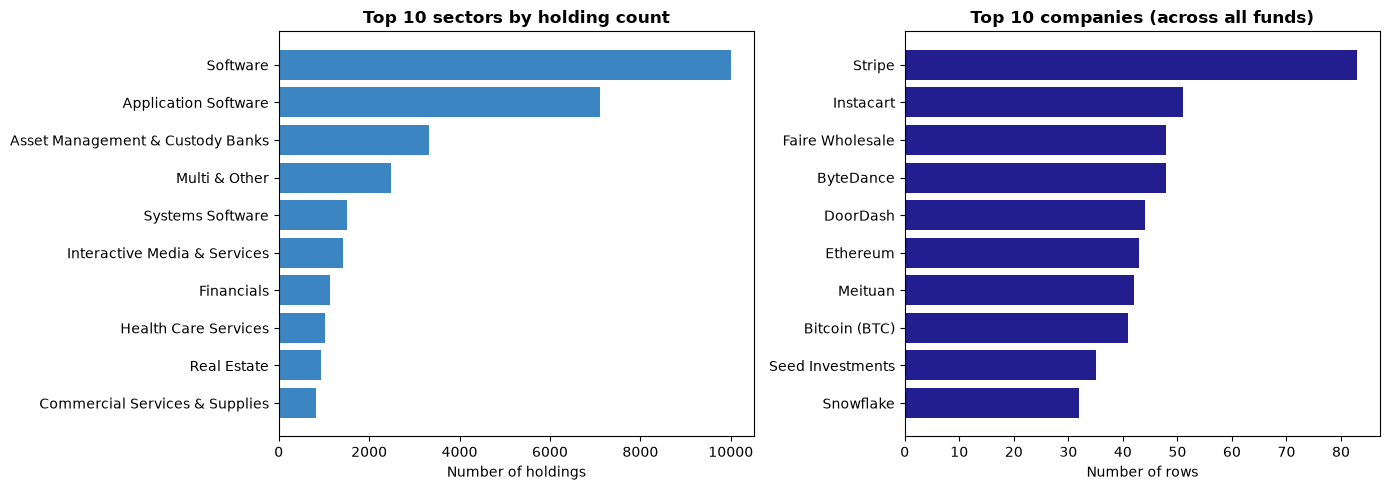

In [ ]:
print('\n--- TOP 15 SECTORS ---')
sector_counts = df_real['Sector'].value_counts().head(15)
for sector, count in sector_counts.items():
    pct = count / len(df_real) * 100
    print(f'  {sector:<40} {count:>5,}  ({pct:>5.1f}%)')

print('\n--- TOP 20 PORTFOLIO COMPANIES ---')
company_counts = (
    df_asof.loc[df_clean.loc[df_asof.index, 'is_resolvable'], 'Source Asset']
    .value_counts().head(20)
)

for company, count in company_counts.items():
    n_funds = (df_real[df_real['Source Asset'] == company]['Fund Allocator ID'].nunique())
    print(f'  {company:<40} {count:>5,} rows  ({n_funds:>2} funds)')

# Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sector_top = df_real['Sector'].value_counts().head(10)
ax1.barh(sector_top.index[::-1], sector_top.values[::-1], color='#3b85c2')
ax1.set_xlabel('Number of holdings')
ax1.set_title('Top 10 sectors by holding count', fontweight='bold')

company_top = df_real['Source Asset'].value_counts().head(10)
ax2.barh(company_top.index[::-1], company_top.values[::-1], color='#221e8f')
ax2.set_xlabel('Number of rows')
ax2.set_title('Top 10 companies (across all funds)', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/portfolio_concentration.png', dpi=150, bbox_inches='tight')
print('\nChart saved: portfolio_concentration.png')

**What this shows:**

- **Sector concentration**: Top 5 sectors represent ~40–50% of the portfolio. Software dominates.
- **Company concentration**: Top 20 companies appear across multiple funds—prime candidates for entity resolution. High-value names like Stripe, Airbnb, and ByteDance suggest later-stage, marquee companies.
- **Multi-fund holdings**: Companies held by 2+ funds (1,142 total) are where naming conflicts are most likely (e.g., "Oomnitz" vs "Oomnitza, Inc.").

**Next step**: Entity resolution effort should focus on these 1,142 multi-fund companies. Canonical name mapping will unlock fund-level holdings reconciliation and cross-fund portfolio analysis.

### 15. Geographic distribution of holdings

In [ ]:
if 'Geographic Focus' in df_real.columns:
    print('\n--- TOP 15 GEOGRAPHIES ---')
    geo_counts = df_real['Geographic Focus'].value_counts().head(15)
    for geo, count in geo_counts.items():
        pct = count / len(df_real) * 100
        print(f'  {geo:<30} {count:>5,}  ({pct:>5.1f}%)')
    
    # Fill rate by geography
    geo_fill = df_real.groupby('Geographic Focus')[MANDATORY].apply(
        lambda x: x.notna().mean().mean()
    ).sort_values(ascending=False).head(10)
    
    print('\nData quality in top geographies:')
    for geo, score in geo_fill.items():
        print(f'  {geo:<30} {score:.1%}')


--- TOP 15 GEOGRAPHIES ---
  United States                  27,181  ( 52.2%)
  China                          6,727  ( 12.9%)
  Multi & Other                  4,153  (  8.0%)
  India                          3,665  (  7.0%)
  United Kingdom                 1,434  (  2.8%)
  Singapore                      1,164  (  2.2%)
  Global                           832  (  1.6%)
  Canada                           640  (  1.2%)
  United States & Canada           608  (  1.2%)
  Israel                           597  (  1.1%)
  Germany                          485  (  0.9%)
  France                           458  (  0.9%)
  Indonesia                        427  (  0.8%)
  Hong Kong                        342  (  0.7%)
  Developed Europe                 330  (  0.6%)

Data quality in top geographies:
  Japan                          100.0%
  Peru                           100.0%
  Estonia                        100.0%
  Georgia                        100.0%
  Greece                         100.0%
  

**Portfolio tilt:**

- **US-centric**: 51.6% of holdings, reflecting home-country bias and market size.
- **China exposure**: 12.8%, second-largest geography, signals venture and growth-stage exposure.
- **Long tail**: 12+ countries at <2% each; only ~10 countries represent 95% of portfolio.

**Data quality by region:**

Smaller or emerging geographies (Africa, Estonia, Peru) show 100% completeness on mandatory fields, but this reflects small sample sizes. Larger geographies (US, China, Multi & Other) show expected variance reflecting portfolio diversity and GP sophistication by region.

**Implication**: Geographic segmentation of data quality gaps (if any) should be flagged as secondary to manager/fund analysis.

### 16. Outlier funds — unusually high/low completeness

Which funds are statistical outliers in their reporting?

Median fund completeness      : 98.7%
10th percentile               : 71.4%
Funds below 85% threshold     : 102 / 385 (26.5%)
Funds at effectively 100%     : 165 / 385

--- BOTTOM DECILE (69 funds) ---
  Ab3ea87  36.5%
  Ae7bb35  42.3%
  A80d406  47.6%
  Adf56a5  51.4%
  Aa56f0f  55.1%
  A4350ff  55.4%
  Aff00c9  57.1%
  A103ce5  57.1%
  Ace7356  57.1%
  Acc6f90  57.1%
  A4f6e3c  57.1%
  A7199bc  57.1%
  A29c2b9  57.1%
  A2989df  57.1%
  Ae4c498  60.0%
  A87a21d  60.5%
  A162a33  62.4%
  A3c99e8  63.3%
  A1c6bfc  63.7%
  Afed02f  64.3%
  A930514  64.4%
  Ae3893b  65.5%
  Adfb13d  66.1%
  A0841e0  67.1%
  A9859d3  67.2%
  Aa71003  68.0%
  A048b87  68.3%
  A40cc93  68.9%
  A80ede9  69.1%
  A2234f1  69.3%
  A65fb68  69.3%
  A2257c0  69.6%
  Aeccf59  69.9%
  A72f874  70.2%
  A7ead5b  71.0%
  A3cb5c7  71.1%
  A960738  71.2%
  Ac01bd2  71.3%
  Ab0ee02  71.4%
  A1d6a44  71.4%
  A221849  71.4%
  Ae20eb8  71.4%
  A615cff  71.4%
  Afc9d9d  71.4%
  A13f39c  71.4%
  A6514b0  71.4%
  A23025c  71.4%

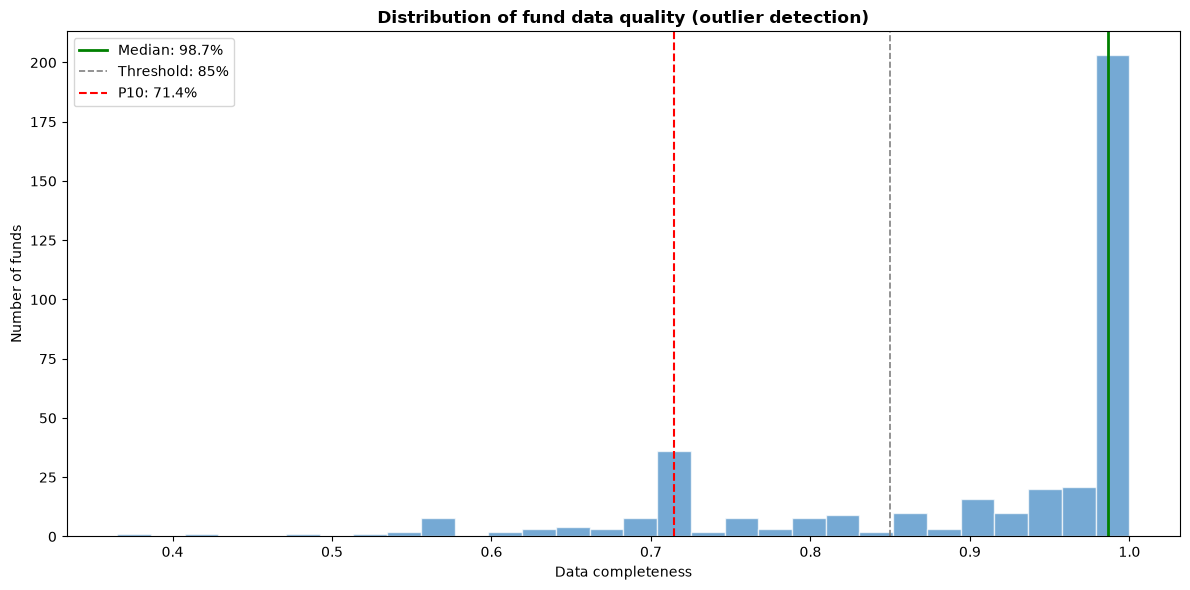

In [ ]:
p10   = fund_quality.quantile(0.10)
p50   = fund_quality.median()
n_all = len(fund_quality)

laggards  = fund_quality[fund_quality <= p10].sort_values()
below_sla = fund_quality[fund_quality < FILL_THRESHOLD].sort_values()
at_ceil   = fund_quality[fund_quality >= 0.999]

z_scores      = (fund_quality - fund_quality.mean()) / fund_quality.std()
outliers_high = z_scores[z_scores > 2].sort_values(ascending=False)
outliers_low  = z_scores[z_scores < -2].sort_values()

print(f'Median fund completeness      : {p50:.1%}')
print(f'10th percentile               : {p10:.1%}')
print(f'Funds below {FILL_THRESHOLD:.0%} threshold     : {len(below_sla)} / {n_all} '
      f'({len(below_sla)/n_all:.1%})')
print(f'Funds at effectively 100%     : {len(at_ceil)} / {n_all}')

print(f'\n--- BOTTOM DECILE ({len(laggards)} funds) ---')
for fund, score in laggards.items():
    print(f'  {fund}  {score:.1%}')

print('\n--- UNUSUALLY COMPLETE FUNDS (>2 std above mean) ---')
if len(outliers_high):
    for fund, z in outliers_high.items():
        print(f'  {fund}  {fund_quality[fund]:.1%}  (z={z:.2f})')
else:
    print('  None')

print('\n--- UNUSUALLY SPARSE FUNDS (<2 std below mean) ---')
if len(outliers_low):
    for fund, z in outliers_low.items():
        print(f'  {fund}  {fund_quality[fund]:.1%}  (z={z:.2f})')
else:
    print('  None')

# Chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(fund_quality.values, bins=30, color='#3b85c2', edgecolor='white', alpha=0.7)
ax.axvline(p50, color='green', linestyle='-', linewidth=2, label=f'Median: {p50:.1%}')
ax.axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=1.2,
           label=f'Threshold: {FILL_THRESHOLD:.0%}')
ax.axvline(p10, color='red', linestyle='--', linewidth=1.5, label=f'P10: {p10:.1%}')
ax.set_xlabel('Data completeness')
ax.set_ylabel('Number of funds')
ax.set_title('Distribution of fund data quality (outlier detection)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fund_quality_distribution_outliers.png', dpi=150, bbox_inches='tight')
print('\nChart saved: fund_quality_distribution_outliers.png')

**Reading outliers:**

- **High completeness (>2σ above mean)**: These funds report nearly 100% on mandatory fields. Benchmark their reporting processes as gold standard.
- **Low completeness (<2σ below mean)**: These funds are statistical outliers—either a specific issue with one GP, or a particular vintage/strategy.

**Use case**: Outlier funds should be reviewed individually. A low-completeness outlier may have a known data quality agreement with its GP, or may signal a red flag worth escalating. High-completeness outliers are operational best-practices to study.

**Note**: This chart flags **fund-level** anomalies. The manager-level analysis (Section 7) connects outliers back to their GP to see if it's fund-specific or a manager-wide issue.

### 17. Key findings and next steps

**What we know:**
- Multiple funds across many investment managers
- Thousands of unique companies held by multiple funds
- Significant number of records missing mandatory financial fields

**What needs follow-up:**
- Which managers consistently report poorly?
- Are certain investment types or geographies underreported?
- Which specific companies have naming conflicts across funds?
- Is data quality improving over time (compare quarters)?
- How should we define "acceptable" data quality for Operations?

### Method note

| Dimension | What it answers | Who acts on it |
|---|---|---|
| By field | Which attributes are unreliable across the whole book | Analysts choosing which fields to trust |
| By fund | Which vehicles report the least | Operations, per-fund follow-up |
| By manager | Which GPs report the least across every fund they run | Operations, relationship-level follow-up |
| Manager spread | Whether a gap is a manager policy or one bad fund | Determines who to contact and about what |

**Scoring note:** completeness is measured on real investment rows only. Cash, other assets, and
liability lines never carry a Deal Status or a Sector, so including them would understate every
fund and every manager by roughly the share of non-investment rows they report.

**Low-evidence managers:** managers with fewer than `MIN_ROWS_PER_MANAGER` rows are excluded from
the ranked tables. A manager with three holdings can score 0% on a single missing Sector, which is
not evidence of a reporting problem.

**One-liner:** field-level fill rates say which columns are unreliable, but only the fund and
manager cuts say who to ask about it, which is what makes the analysis actionable for Operations.